In [23]:
import pandas as pd
import numpy as np
import os
import glob
import shutil
import scipy.stats as stats
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d
import sys

In [24]:
import Waveform_Isolation as WI

# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join('Simulated_Waveforms', '*.csv')
channel_files = glob.glob(search_path)

results = [] # This list will be passed by reference to accumulate results

if not channel_files:
    print(f"No channel files found in {search_path}")
    sys.exit()

# Read all channels into a dictionary of dataframes, to be used later
# At the same time, process each channel and isolate the waveforms
print(f"Loading {len(channel_files)} channel files into memory...")
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        channel_dataframes[filename] = df
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

    # After processing all files, save the accumulated results to a single CSV
indices_df = pd.read_csv('Waveform_Analysis.csv')

Loading 4 channel files into memory...


In [25]:
import Envelope_Analysis as EA

EA.cluster_waveforms(channel_dataframes)

Processing Ch1.csv_#1...
Processing Ch1.csv_#2...
  Comparing vs Group 1: D = 1.0933
  -> No match. Created Group 2.
Processing Ch1.csv_#3...
  Comparing vs Group 1: D = 0.1849
  -> Match found! Added to Group 1.
Processing Ch1.csv_#4...
  Comparing vs Group 1: D = 0.6561
  Comparing vs Group 2: D = 1.2769
  -> No match. Created Group 3.
Processing Ch1.csv_#5...
  Comparing vs Group 1: D = 0.6115
  Comparing vs Group 2: D = 1.1156
  Comparing vs Group 3: D = 0.4413
  -> Match found! Added to Group 3.
Processing Ch1.csv_#6...
  Comparing vs Group 1: D = 0.6198
  Comparing vs Group 2: D = 1.2829
  Comparing vs Group 3: D = 0.2362
  -> Match found! Added to Group 3.
Processing Ch2.csv_#1...
  Comparing vs Group 1: D = 0.5188
  Comparing vs Group 2: D = 1.0115
  Comparing vs Group 3: D = 0.6445
  -> No match. Created Group 4.
Processing Ch2.csv_#2...
  Comparing vs Group 1: D = 0.6264
  Comparing vs Group 2: D = 0.6879
  Comparing vs Group 3: D = 0.8477
  Comparing vs Group 4: D = 0.4182
 

{1: [[['Ch1.csv', np.int64(1)], ['Ch1.csv', np.int64(3)]],
  array([0.07955251, 0.07951154, 0.07946187, ..., 0.17023292, 0.17032675,
         0.17042352], shape=(6296,))],
 2: [[['Ch1.csv', np.int64(2)], ['Ch4.csv', np.int64(2)]],
  array([0.96211314, 0.96112937, 0.95996678, ..., 1.20963875, 1.2112246 ,
         1.21274053], shape=(6290,))],
 3: [[['Ch1.csv', np.int64(4)],
   ['Ch1.csv', np.int64(5)],
   ['Ch1.csv', np.int64(6)]],
  array([0.05072123, 0.05065791, 0.0505935 , ..., 0.07179926, 0.07183488,
         0.07184284], shape=(6270,))],
 4: [[['Ch2.csv', np.int64(1)],
   ['Ch2.csv', np.int64(2)],
   ['Ch2.csv', np.int64(3)],
   ['Ch3.csv', np.int64(1)],
   ['Ch3.csv', np.int64(2)],
   ['Ch3.csv', np.int64(3)],
   ['Ch4.csv', np.int64(1)],
   ['Ch4.csv', np.int64(3)]],
  array([0.56562542, 0.56906662, 0.5726137 , ..., 0.41038207, 0.40915282,
         0.40798644], shape=(5868,))],
 5: [[['Ch2.csv', np.int64(4)],
   ['Ch2.csv', np.int64(5)],
   ['Ch2.csv', np.int64(6)]],
  array([0.1

In [26]:
import Wavelet_Decomposition as WD
# 2. Pre-load channel files into memory


# 3. Process each isolated waveform
print(f"Extracting features for {len(indices_df)} waveforms...")

results = []

for i, row in indices_df.iterrows():
    filename = row['input filename']
    start_idx = int(row['start idx'])
    end_idx = int(row['end idx'])
    count = row['count']
    
    # Extract signal from the pre-loaded dataframes
    try:
        df = channel_dataframes[filename]
        signal_segment = df.iloc[start_idx:end_idx, 1].values
        
        # Extract features
        energies = WD.calculate_wavelet_energy(signal_segment)
        
        if energies is not None:
            res_row = {
                'input filename': filename,
                'count': count,
                'Energy_A5': energies[0],
                'Energy_D5': energies[1],
                'Energy_D4': energies[2],
                'Energy_D3': energies[3],
                'Energy_D2': energies[4],
                'Energy_D1': energies[5]
            }
            results.append(res_row)
            
    except Exception as e:
        print(f"Error processing {filename} #{count}: {e}")

# 4. Save results to CSV
if results:
    new_df = pd.DataFrame(results)
        
    if os.path.exists(WD.OUTPUT_FILE):
        existing_df = pd.read_csv(WD.OUTPUT_FILE)
        # Merge new results as columns. 
        # We assume 'Filename' is the common identifier for rows.
        if 'input filename' in existing_df.columns and 'count' in existing_df.columns:
            # Merge on Filename and Count to ensure rows match correctly
            # 'outer' join ensures we don't lose rows
            final_df = pd.merge(existing_df, new_df, on=['input filename', 'count'], how='outer')
        else:
            # Fallback: if keys are missing, just concatenate columns
            final_df = pd.concat([existing_df, new_df], axis=1)
        
        final_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data appended as columns to {WD.OUTPUT_FILE}")
    else:
        new_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data saved to {WD.OUTPUT_FILE}")
else:
    print("No features extracted.")

Extracting features for 24 waveforms...
Processing complete. Data appended as columns to Waveform_Analysis.csv


Loading data from Waveform_Analysis.csv...
Computing Principal Components...
Explained Variance by component: [0.85223185 0.14064893 0.00584973]
Total Information Retained: 99.87%
PCA results appended to Waveform_Analysis.csv
Generating 3D Plot...


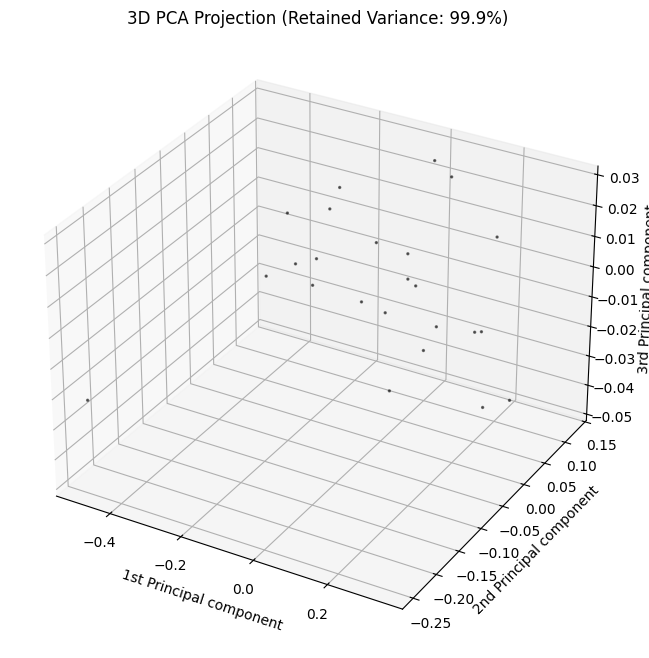

In [27]:
import Principal_Component_Analysis as pca

pca.perform_pca_and_visualize('Waveform_Analysis.csv')

Loading data from Waveform_Analysis.csv...
Running DBSCAN with eps=0.1 and min_samples=2...
Estimated number of clusters: 3
Estimated number of noise points: 1
Clustered data saved back to Waveform_Analysis.csv
Generating 3D Cluster Plot...


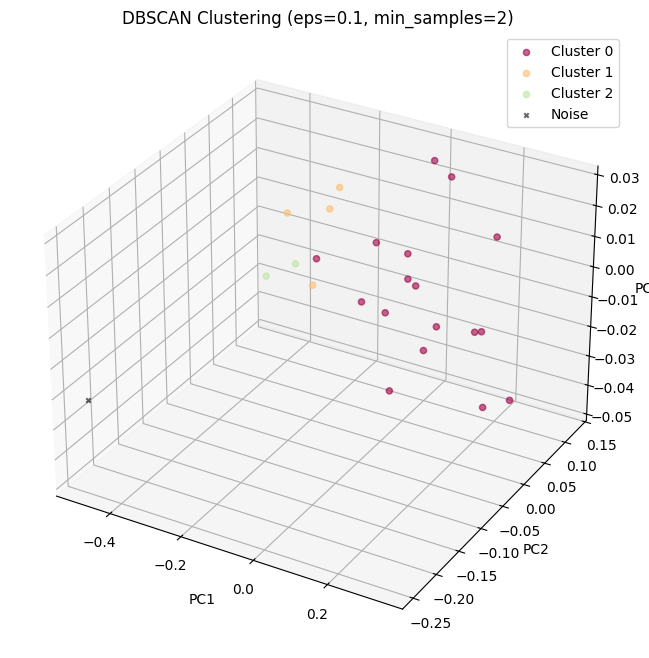

In [31]:
import DBSCAN as dbscan

dbscan.perform_dbscan_clustering('Waveform_Analysis.csv', epsilon=0.1, min_samples=2)